In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

In [43]:
class LinearRegressionGD: 
    def __init__(self, learning_rate = 0.01, epochs = 1000): 
        self.learning_rate = learning_rate 
        self.epochs = epochs 
        self.weights = None 
        self.bias = 0 
        self.loss_history = []

    def fit(self, X, y): 

        # no.of obs and feature 
        n_samples, n_features = X.shape 

        # Initialize weights and bias 
        self.weights = np.zeros(n_features)
        self.bias = 0 

        for epoch in range(self.epochs):
            # prediction 
            y_pred = X @ self.weights + self.bias 

            # error 
            error = y_pred - y 

            # gradient decents 
            dw = (1 / n_samples) * (X.T @ error)
            db = (1 / n_samples) * np.sum(error) 

            # update parameters 
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # loss 
            loss = (1 / (2 * n_samples)) * np.sum(error ** 2)
            self.loss_history.append(loss) 

            

    def predict(self, X): 
        return X @ self.weights + self.bias 
        
        

In [44]:
# Sample Dataset 
X = np.array([
    [1200, 2, 10],
    [1500, 3, 8],
    [1800, 3, 5],
    [2000, 4, 3]
], dtype=float)

y = np.array([200, 250, 320, 400], dtype=float)

In [45]:
# Feature Scaling 
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.40213637, -1.41421356,  1.29986737],
       [-0.41239305,  0.        ,  0.55708601],
       [ 0.57735027,  0.        , -0.55708601],
       [ 1.23717915,  1.41421356, -1.29986737]])

In [46]:
# Train Model 
model = LinearRegressionGD(learning_rate=0.01, epochs=1000)
model.fit(X_scaled, y)

print(f"Weight(w): {model.weights}")
print(f"Bias(b): {model.bias}")

Weight(w): [ 24.44786714  16.98161443 -34.12048428]
Bias(b): 292.4873724101324


In [47]:
# Prediction 

new_house = np.array([[1700, 3, 6]])

new_house_scaled = scaler.transform(new_house)

prediction = model.predict(new_house_scaled)

print(prediction)

[304.87266557]


In [48]:
# New Dataset 
X_new = np.array([[1],[2],[3],[4],[5],[6]], dtype=float)
y_new = np.array([2,4,6,8,10,12], dtype=float)

new_model = LinearRegressionGD()
new_model.fit(X_new, y_new)

y_pred = new_model.predict(X_new)
print(f"Weights(w): {new_model.weights}")
print(f"Bias(b): {new_model.bias}")
print(f"Prediction: {y_pred.round(2)}")


Weights(w): [1.98334139]
Bias(b): 0.07131883444720377
Prediction: [ 2.05  4.04  6.02  8.    9.99 11.97]


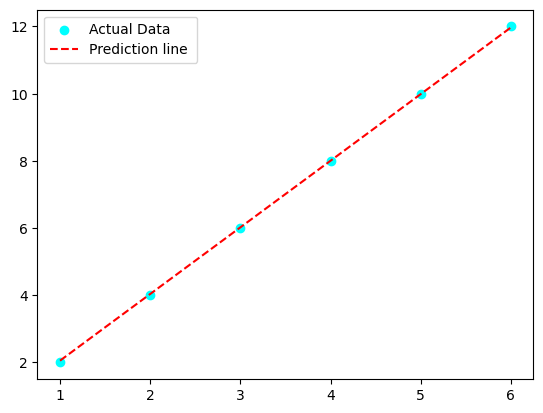

In [49]:
# Visualize prediction 
plt.scatter(x=X_new, y=y_new, label='Actual Data', marker='o', color='cyan')
plt.plot(X_new, y_pred, 'r--', label='Prediction line ')
plt.legend()
plt.show()

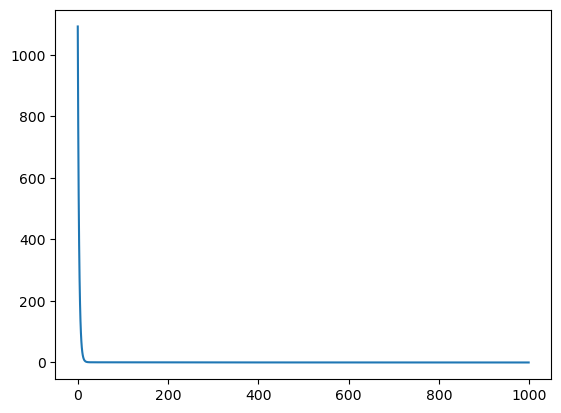

In [41]:
# Visualize Loss 
plt.plot(new_model.loss_history)
plt.show()